# Action Plan Scoring Evaluation

This notebook evaluates action plans using BERTScore, BLEU, and ROUGE metrics against a reference text for DDoS mitigation actions. It extracts `overall_reasoning` from comparison files for scoring.

## Reference Text
Rate limiting on RAN. Rate limiting on Edge. Rate limiting on Core. Traffic scrubbing on Core. Blackhole routing on Core. ACL update on RAN. ACL update on Edge. ACL update on Core. IP blocking on RAN. IP blocking on Edge. IP blocking on Core.

In [1]:
# Import required libraries
import json
import os
from pathlib import Path
from typing import Dict, List, Tuple, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scoring libraries
from bert_score import score as bert_score
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Download required NLTK data
import nltk
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt', quiet=True)

# Initialize SBERT model (load once, reuse)
print("Loading SBERT model...")
sbert_model = SentenceTransformer('all-MiniLM-L6-v2')
print("Libraries imported successfully!")

Loading SBERT model...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Libraries imported successfully!


## Configuration

In [2]:
# Configuration
RAG_DOCS_DIR = Path("RAG_docs/action_plans")
REFERENCE_TEXT = "Rate limiting on RAN. Rate limiting on Edge. Rate limiting on Core. Traffic scrubbing on Core. Blackhole routing on Core. ACL update on RAN. ACL update on Edge. ACL update on Core. IP blocking on RAN. IP blocking on Edge. IP blocking on Core."

print(f"Action plans directory: {RAG_DOCS_DIR}")
print(f"Reference text: {REFERENCE_TEXT}")

Action plans directory: RAG_docs\action_plans
Reference text: Rate limiting on RAN. Rate limiting on Edge. Rate limiting on Core. Traffic scrubbing on Core. Blackhole routing on Core. ACL update on RAN. ACL update on Edge. ACL update on Core. IP blocking on RAN. IP blocking on Edge. IP blocking on Core.


## Helper Functions

In [3]:
def extract_overall_reasoning(action_plan: Dict[str, Any]) -> str:
    """
    Extract overall_reasoning from an action plan.
    Returns the overall_reasoning text if available, otherwise empty string.
    """
    overall_reasoning = action_plan.get("overall_reasoning", "").strip()
    return overall_reasoning if overall_reasoning else ""


def load_comparison_files(directory: Path) -> List[Dict[str, Any]]:
    """Load all comparison JSON files from the directory."""
    comparison_files = list(directory.glob("comparison*.json"))
    print(f"Found {len(comparison_files)} comparison file(s)")
    
    loaded_data = []
    for file_path in comparison_files:
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                data['file_path'] = str(file_path)
                data['file_name'] = file_path.name
                loaded_data.append(data)
                print(f"  - Loaded: {file_path.name}")
        except Exception as e:
            print(f"  - Error loading {file_path.name}: {e}")
    
    return loaded_data


def calculate_bleu_score(reference: str, candidate: str) -> float:
    """Calculate BLEU score between reference and candidate texts."""
    # Tokenize
    ref_tokens = reference.lower().split()
    cand_tokens = candidate.lower().split()
    
    # Use smoothing function to handle cases where n-grams don't match
    smoothing = SmoothingFunction().method1
    score = sentence_bleu([ref_tokens], cand_tokens, smoothing_function=smoothing)
    return score


def calculate_rouge1_score(reference: str, candidate: str) -> float:
    """Calculate ROUGE-1 score only."""
    scorer = rouge_scorer.RougeScorer(['rouge1'], use_stemmer=True)
    scores = scorer.score(reference, candidate)
    return scores['rouge1'].fmeasure


def calculate_sbert_cosine(reference: str, candidate: str) -> float:
    """Calculate SBERT cosine similarity between reference and candidate texts."""
    # Get embeddings
    ref_embedding = sbert_model.encode([reference])
    cand_embedding = sbert_model.encode([candidate])
    
    # Calculate cosine similarity
    cosine_sim = cosine_similarity(ref_embedding, cand_embedding)[0][0]
    return float(cosine_sim)


def calculate_bertscore_scores(references: List[str], candidates: List[str]) -> Dict[str, float]:
    """Calculate BERTScore (precision, recall, F1) for multiple reference-candidate pairs."""
    # BERTScore expects lists of strings
    P, R, F1 = bert_score(candidates, references, lang='en', verbose=False)
    
    return {
        'bertscore_precision': P.mean().item(),
        'bertscore_recall': R.mean().item(),
        'bertscore_f1': F1.mean().item()
    }

print("Helper functions defined!")

Helper functions defined!


## Load Comparison Files

In [4]:
# Load all comparison files
comparison_data = load_comparison_files(RAG_DOCS_DIR)

if not comparison_data:
    print("No comparison files found!")
else:
    print(f"\nTotal comparison files loaded: {len(comparison_data)}")

Found 2 comparison file(s)
  - Loaded: comparison_sample_0_20260210_152216.json
  - Loaded: comparison_sample_0_20260210_152945.json

Total comparison files loaded: 2


## Extract Overall Reasoning and Calculate Scores

In [5]:
# Extract overall_reasoning from action plans and prepare for scoring
scoring_results = []

for comp_data in comparison_data:
    file_name = comp_data['file_name']
    sample_id = comp_data.get('sample_id', 'unknown')
    
    # Extract with RAG overall_reasoning
    with_rag_plan = comp_data.get('action_plans', {}).get('with_rag', {})
    with_rag_text = extract_overall_reasoning(with_rag_plan)
    
    # Extract without RAG overall_reasoning
    without_rag_plan = comp_data.get('action_plans', {}).get('without_rag', {})
    without_rag_text = extract_overall_reasoning(without_rag_plan)
    
    print(f"\n{'='*60}")
    print(f"File: {file_name} (Sample ID: {sample_id})")
    print(f"{'='*60}")
    print(f"With RAG overall_reasoning: {with_rag_text}")
    print(f"Without RAG overall_reasoning: {without_rag_text}")
    
    # Calculate scores for with RAG
    if with_rag_text:
        bleu_with = calculate_bleu_score(REFERENCE_TEXT, with_rag_text)
        rouge1_with = calculate_rouge1_score(REFERENCE_TEXT, with_rag_text)
        sbert_cosine_with = calculate_sbert_cosine(REFERENCE_TEXT, with_rag_text)
        bertscore_with = calculate_bertscore_scores([REFERENCE_TEXT], [with_rag_text])
        
        scoring_results.append({
            'file_name': file_name,
            'sample_id': sample_id,
            'method': 'with_rag',
            'text': with_rag_text,
            'bleu': bleu_with,
            'rouge1': rouge1_with,
            'sbert_cosine': sbert_cosine_with,
            'bertscore_precision': bertscore_with['bertscore_precision'],
            'bertscore_recall': bertscore_with['bertscore_recall'],
            'bertscore_f1': bertscore_with['bertscore_f1']
        })
    
    # Calculate scores for without RAG
    if without_rag_text:
        bleu_without = calculate_bleu_score(REFERENCE_TEXT, without_rag_text)
        rouge1_without = calculate_rouge1_score(REFERENCE_TEXT, without_rag_text)
        sbert_cosine_without = calculate_sbert_cosine(REFERENCE_TEXT, without_rag_text)
        bertscore_without = calculate_bertscore_scores([REFERENCE_TEXT], [without_rag_text])
        
        scoring_results.append({
            'file_name': file_name,
            'sample_id': sample_id,
            'method': 'without_rag',
            'text': without_rag_text,
            'bleu': bleu_without,
            'rouge1': rouge1_without,
            'sbert_cosine': sbert_cosine_without,
            'bertscore_precision': bertscore_without['bertscore_precision'],
            'bertscore_recall': bertscore_without['bertscore_recall'],
            'bertscore_f1': bertscore_without['bertscore_f1']
        })

print(f"\n\nTotal scoring results: {len(scoring_results)}")


File: comparison_sample_0_20260210_152216.json (Sample ID: 0)
With RAG overall_reasoning: The RAN is prioritized for the primary action due to its dominant contribution to the DDOS attack, followed by the Edge tier for supporting actions. The actions selected are aggressive due to the 100% confidence in the DDOS prediction, ensuring immediate mitigation efforts are taken to protect the network.
Without RAG overall_reasoning: The attack is predicted with 100% confidence, indicating an imminent threat. The selected actions are appropriate for a DDoS attack, focusing on immediate mitigation.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/389 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




Total scoring results: 4


## Create Results DataFrame

In [6]:
# Create DataFrame for easier analysis
df_results = pd.DataFrame(scoring_results)

if not df_results.empty:
    print("Scoring Results DataFrame:")
    print(df_results[['file_name', 'method', 'bleu', 'rouge1', 'sbert_cosine', 
                      'bertscore_precision', 'bertscore_recall', 'bertscore_f1']].to_string())
else:
    print("No results to display!")

Scoring Results DataFrame:
                                  file_name       method      bleu    rouge1  sbert_cosine  bertscore_precision  bertscore_recall  bertscore_f1
0  comparison_sample_0_20260210_152216.json     with_rag  0.000000  0.043011      0.518151             0.825394          0.825823      0.825608
1  comparison_sample_0_20260210_152216.json  without_rag  0.003439  0.029412      0.283274             0.832349          0.806891      0.819422
2  comparison_sample_0_20260210_152945.json     with_rag  0.000000  0.066667      0.553451             0.829073          0.835771      0.832409
3  comparison_sample_0_20260210_152945.json  without_rag  0.000000  0.000000      0.337081             0.832256          0.799665      0.815635


## Calculate Average Scores

In [7]:
# Calculate average scores by method (with_rag vs without_rag)
if not df_results.empty:
    avg_scores = df_results.groupby('method').agg({
        'bleu': 'mean',
        'rouge1': 'mean',
        'sbert_cosine': 'mean',
        'bertscore_precision': 'mean',
        'bertscore_recall': 'mean',
        'bertscore_f1': 'mean'
    }).round(4)
    
    print("\nAverage Scores by Method:")
    print("="*60)
    print(avg_scores.to_string())
    
    # Also calculate overall averages
    overall_avg = df_results[['bleu', 'rouge1', 'sbert_cosine', 
                               'bertscore_precision', 'bertscore_recall', 'bertscore_f1']].mean()
    
    print("\n\nOverall Average Scores (across all methods):")
    print("="*60)
    for metric, value in overall_avg.items():
        print(f"{metric:25s}: {value:.4f}")
else:
    print("No results to calculate averages!")


Average Scores by Method:
               bleu  rouge1  sbert_cosine  bertscore_precision  bertscore_recall  bertscore_f1
method                                                                                        
with_rag     0.0000  0.0548        0.5358               0.8272            0.8308        0.8290
without_rag  0.0017  0.0147        0.3102               0.8323            0.8033        0.8175


Overall Average Scores (across all methods):
bleu                     : 0.0009
rouge1                   : 0.0348
sbert_cosine             : 0.4230
bertscore_precision      : 0.8298
bertscore_recall         : 0.8170
bertscore_f1             : 0.8233


## Visualizations: Bar Charts

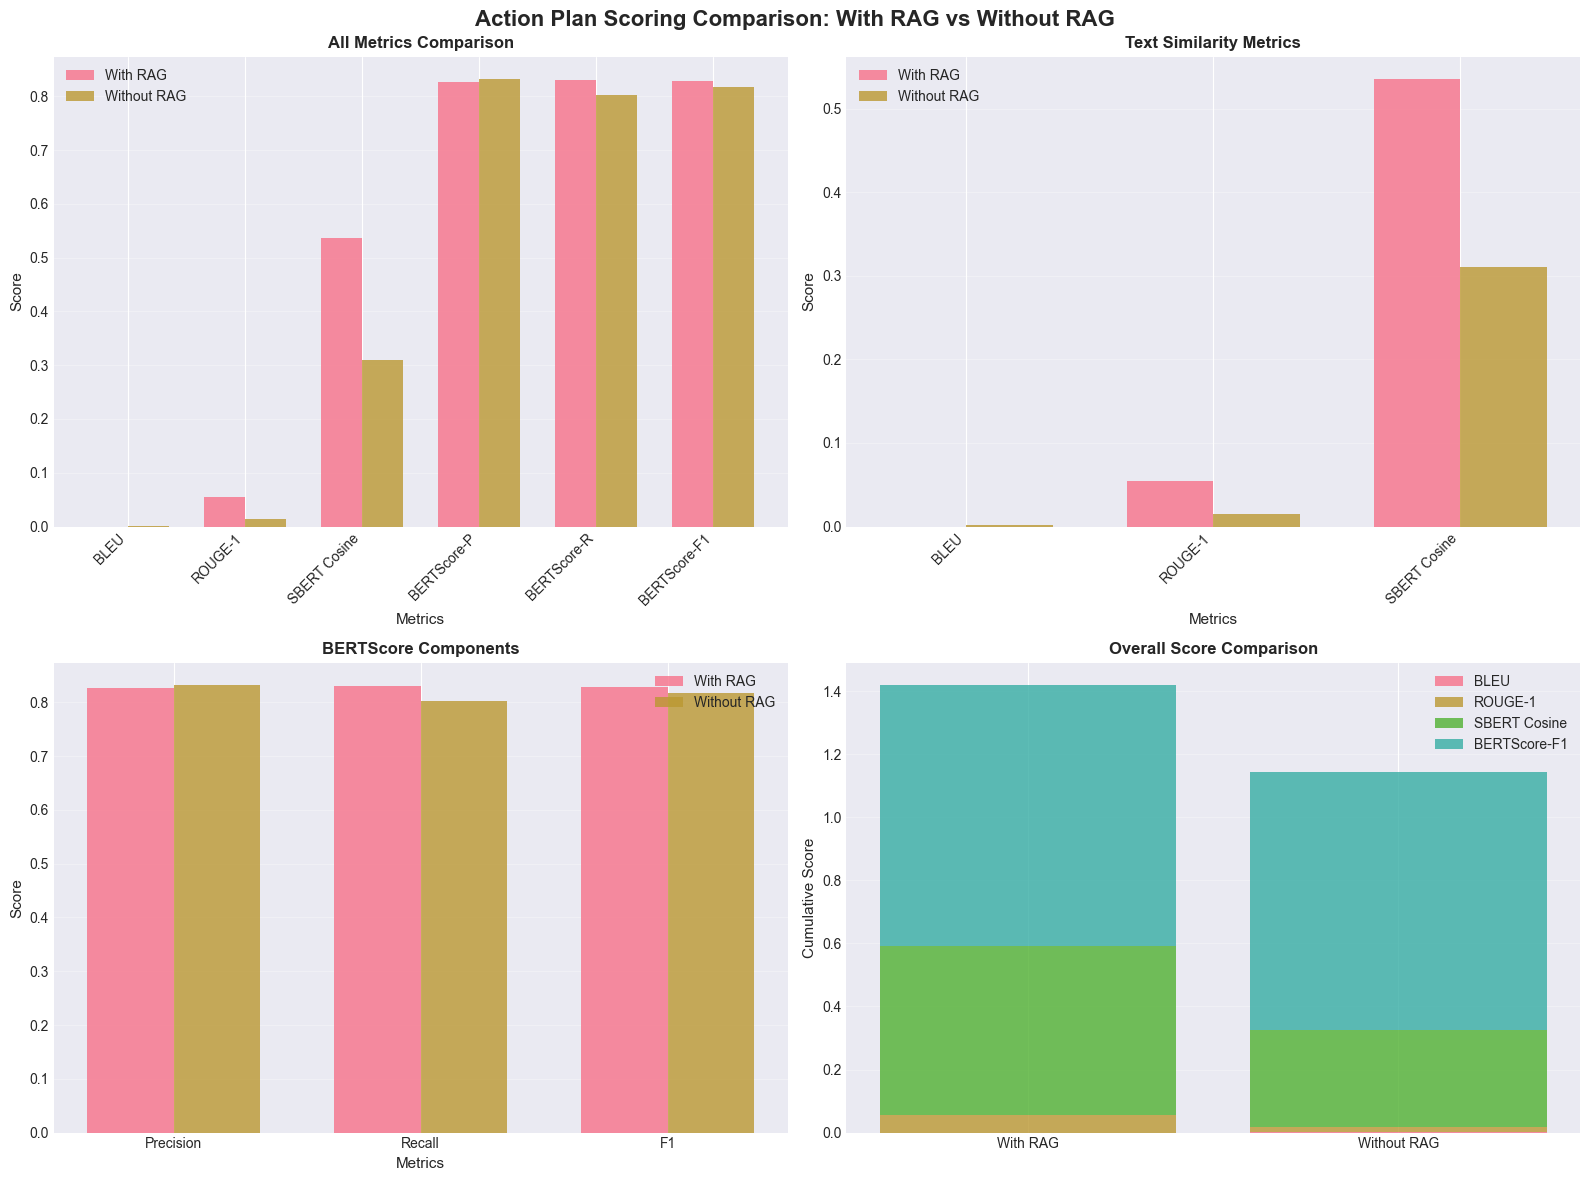


Visualizations created successfully!


In [8]:
# Set up plotting style
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')
sns.set_palette("husl")

# Create visualizations
if not df_results.empty and len(df_results) > 0:
    # Prepare data for plotting
    metrics = ['bleu', 'rouge1', 'sbert_cosine', 'bertscore_precision', 'bertscore_recall', 'bertscore_f1']
    metric_labels = ['BLEU', 'ROUGE-1', 'SBERT Cosine', 'BERTScore-P', 'BERTScore-R', 'BERTScore-F1']
    
    # Calculate averages by method
    avg_scores = df_results.groupby('method')[metrics].mean()
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('Action Plan Scoring Comparison: With RAG vs Without RAG', fontsize=16, fontweight='bold')
    
    # 1. All metrics comparison
    ax1 = axes[0, 0]
    x = np.arange(len(metrics))
    width = 0.35
    
    if 'with_rag' in avg_scores.index:
        with_rag_values = [avg_scores.loc['with_rag', metric] for metric in metrics]
        ax1.bar(x - width/2, with_rag_values, width, label='With RAG', alpha=0.8)
    
    if 'without_rag' in avg_scores.index:
        without_rag_values = [avg_scores.loc['without_rag', metric] for metric in metrics]
        ax1.bar(x + width/2, without_rag_values, width, label='Without RAG', alpha=0.8)
    
    ax1.set_xlabel('Metrics', fontsize=11)
    ax1.set_ylabel('Score', fontsize=11)
    ax1.set_title('All Metrics Comparison', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(metric_labels, rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # 2. BLEU, ROUGE-1, and SBERT Cosine
    ax2 = axes[0, 1]
    text_metrics = ['bleu', 'rouge1', 'sbert_cosine']
    text_labels = ['BLEU', 'ROUGE-1', 'SBERT Cosine']
    x2 = np.arange(len(text_metrics))
    
    if 'with_rag' in avg_scores.index:
        with_rag_values = [avg_scores.loc['with_rag', metric] for metric in text_metrics]
        ax2.bar(x2 - width/2, with_rag_values, width, label='With RAG', alpha=0.8)
    
    if 'without_rag' in avg_scores.index:
        without_rag_values = [avg_scores.loc['without_rag', metric] for metric in text_metrics]
        ax2.bar(x2 + width/2, without_rag_values, width, label='Without RAG', alpha=0.8)
    
    ax2.set_xlabel('Metrics', fontsize=11)
    ax2.set_ylabel('Score', fontsize=11)
    ax2.set_title('Text Similarity Metrics', fontsize=12, fontweight='bold')
    ax2.set_xticks(x2)
    ax2.set_xticklabels(text_labels, rotation=45, ha='right')
    ax2.legend()
    ax2.grid(axis='y', alpha=0.3)
    
    # 3. BERTScore components
    ax3 = axes[1, 0]
    bert_metrics = ['bertscore_precision', 'bertscore_recall', 'bertscore_f1']
    bert_labels = ['Precision', 'Recall', 'F1']
    x3 = np.arange(len(bert_metrics))
    
    if 'with_rag' in avg_scores.index:
        with_rag_values = [avg_scores.loc['with_rag', metric] for metric in bert_metrics]
        ax3.bar(x3 - width/2, with_rag_values, width, label='With RAG', alpha=0.8)
    
    if 'without_rag' in avg_scores.index:
        without_rag_values = [avg_scores.loc['without_rag', metric] for metric in bert_metrics]
        ax3.bar(x3 + width/2, without_rag_values, width, label='Without RAG', alpha=0.8)
    
    ax3.set_xlabel('Metrics', fontsize=11)
    ax3.set_ylabel('Score', fontsize=11)
    ax3.set_title('BERTScore Components', fontsize=12, fontweight='bold')
    ax3.set_xticks(x3)
    ax3.set_xticklabels(bert_labels)
    ax3.legend()
    ax3.grid(axis='y', alpha=0.3)
    
    # 4. Overall comparison (stacked or grouped)
    ax4 = axes[1, 1]
    methods = ['With RAG', 'Without RAG'] if 'with_rag' in avg_scores.index and 'without_rag' in avg_scores.index else []
    if methods:
        overall_metrics = ['bleu', 'rouge1', 'sbert_cosine', 'bertscore_f1']
        overall_labels = ['BLEU', 'ROUGE-1', 'SBERT Cosine', 'BERTScore-F1']
        
        x4 = np.arange(len(methods))
        bottom = np.zeros(len(methods))
        
        for i, metric in enumerate(overall_metrics):
            values = []
            if 'with_rag' in avg_scores.index:
                values.append(avg_scores.loc['with_rag', metric])
            if 'without_rag' in avg_scores.index:
                values.append(avg_scores.loc['without_rag', metric])
            
            if values:
                ax4.bar(methods, values, label=overall_labels[i], alpha=0.8, bottom=bottom[:len(values)])
                bottom[:len(values)] += np.array(values)
        
        ax4.set_ylabel('Cumulative Score', fontsize=11)
        ax4.set_title('Overall Score Comparison', fontsize=12, fontweight='bold')
        ax4.legend()
        ax4.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nVisualizations created successfully!")
else:
    print("No data available for visualization!")

In [9]:
# Display individual file scores
if not df_results.empty:
    print("\nIndividual File Scores:")
    print("="*80)
    
    for file_name in df_results['file_name'].unique():
        file_data = df_results[df_results['file_name'] == file_name]
        print(f"\nFile: {file_name}")
        print("-" * 80)
        
        for _, row in file_data.iterrows():
            print(f"\nMethod: {row['method'].upper()}")
            print(f"  BLEU:              {row['bleu']:.4f}")
            print(f"  ROUGE-1:           {row['rouge1']:.4f}")
            print(f"  SBERT Cosine:      {row['sbert_cosine']:.4f}")
            print(f"  BERTScore-P:       {row['bertscore_precision']:.4f}")
            print(f"  BERTScore-R:       {row['bertscore_recall']:.4f}")
            print(f"  BERTScore-F1:      {row['bertscore_f1']:.4f}")
            print(f"  Overall Reasoning: {row['text'][:100]}..." if len(row['text']) > 100 else f"  Overall Reasoning: {row['text']}")
else:
    print("No results to display!")


Individual File Scores:

File: comparison_sample_0_20260210_152216.json
--------------------------------------------------------------------------------

Method: WITH_RAG
  BLEU:              0.0000
  ROUGE-1:           0.0430
  SBERT Cosine:      0.5182
  BERTScore-P:       0.8254
  BERTScore-R:       0.8258
  BERTScore-F1:      0.8256
  Overall Reasoning: The RAN is prioritized for the primary action due to its dominant contribution to the DDOS attack, f...

Method: WITHOUT_RAG
  BLEU:              0.0034
  ROUGE-1:           0.0294
  SBERT Cosine:      0.2833
  BERTScore-P:       0.8323
  BERTScore-R:       0.8069
  BERTScore-F1:      0.8194
  Overall Reasoning: The attack is predicted with 100% confidence, indicating an imminent threat. The selected actions ar...

File: comparison_sample_0_20260210_152945.json
--------------------------------------------------------------------------------

Method: WITH_RAG
  BLEU:              0.0000
  ROUGE-1:           0.0667
  SBERT Cosine:   

## Save Results to JSON

In [10]:
# Save detailed results to JSON
if scoring_results:
    # Create scoring directory under RAG_docs
    scoring_dir = Path("RAG_docs/scoring")
    scoring_dir.mkdir(parents=True, exist_ok=True)
    
    output_file = scoring_dir / "scoring_results.json"
    
    # Prepare output data
    output_data = {
        'reference_text': REFERENCE_TEXT,
        'total_files': len(comparison_data),
        'timestamp': pd.Timestamp.now().isoformat(),
        'individual_scores': scoring_results,
        'average_scores': {}
    }
    
    # Add average scores
    if not df_results.empty:
        for method in df_results['method'].unique():
            method_data = df_results[df_results['method'] == method]
            output_data['average_scores'][method] = {
                'bleu': float(method_data['bleu'].mean()),
                'rouge1': float(method_data['rouge1'].mean()),
                'sbert_cosine': float(method_data['sbert_cosine'].mean()),
                'bertscore_precision': float(method_data['bertscore_precision'].mean()),
                'bertscore_recall': float(method_data['bertscore_recall'].mean()),
                'bertscore_f1': float(method_data['bertscore_f1'].mean())
            }
    
    # Save to file
    with open(output_file, 'w', encoding='utf-8') as f:
        json.dump(output_data, f, indent=2, ensure_ascii=False)
    
    print(f"Results saved to: {output_file}")
else:
    print("No results to save!")

Results saved to: RAG_docs\scoring\scoring_results.json
